# Business Sales Performance Analytics
**Future Interns — Data Science & Analytics Internship**  
**Task 1 | CIN: FIT/APR26/DS16450 | Intern: Prisha K**  
**GitHub Repo:** `FUTURE_DS_01`

---

## Objective
Analyze business sales data to identify:
1. Revenue trends over time
2. Top-selling products
3. High-value categories
4. Regional performance

**Tools used:** Python, Pandas, Matplotlib, Seaborn

## 1. Setup — Import Libraries & Load Data

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'axes.spines.top': False,
                     'axes.spines.right': False})

df = pd.read_csv('sales_data_FUTURE_DS_01.csv', parse_dates=['Date'])
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (200, 9)


,Order_ID,Date,Region,Category,Product_Name,Units_Sold,Unit_Price_INR,Revenue_INR,Profit_INR
0,ORD-031,2025-01-01,East,Food & Beverages,Protein Bars (10pk),4,300,1200,480
1,ORD-192,2025-01-01,West,Food & Beverages,Protein Bars (10pk),7,300,2100,840
2,ORD-173,2025-01-02,West,Food & Beverages,Organic Honey 500g,20,450,9000,3420
3,ORD-121,2025-01-04,East,Clothing,Winter Jacket,7,4500,31500,11025
4,ORD-069,2025-01-05,East,Electronics,"Monitor 24""",5,18000,90000,18000
5,ORD-150,2025-01-06,South,Electronics,Wireless Mouse,24,1200,28800,8640
6,ORD-163,2025-01-07,East,Food & Beverages,Green Tea 100pk,15,250,3750,1575
7,ORD-104,2025-01-13,North,Furniture,Bean Bag,10,3200,32000,11200
8,ORD-137,2025-01-14,East,Books & Stationery,Whiteboard Markers,30,180,5400,2700
9,ORD-018,2025-01-17,East,Food & Beverages,Energy Drink (24pk),3,150,450,180


## 2. Data Cleaning & Overview

In [18]:
# Check for nulls and duplicates
print("=== Data Quality Check ===")
print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Date range     : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Unique products: {df['Product_Name'].nunique()}")
print(f"Unique regions : {df['Region'].nunique()}")
print()

# Add time columns
df['Month']   = df['Date'].dt.to_period('M')
df['Quarter'] = df['Date'].dt.to_period('Q')
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Month_Num']  = df['Date'].dt.month

print("Cleaned columns added: Month, Quarter, Month_Name")
df.dtypes

=== Data Quality Check ===
Missing values : 0
Duplicate rows : 0
Date range     : 2025-01-01 to 2025-12-29
Unique products: 39
Unique regions : 4

Cleaned columns added: Month, Quarter, Month_Name


Order_ID                  object
Date              datetime64[ns]
Region                    object
Category                  object
Product_Name              object
Units_Sold                 int64
Unit_Price_INR             int64
Revenue_INR                int64
Profit_INR                 int64
Month                  period[M]
Quarter            period[Q-DEC]
Month_Name                object
Month_Num                  int32
dtype: object

In [19]:
# Summary statistics
df[['Units_Sold','Unit_Price_INR','Revenue_INR','Profit_INR']].describe().round(0)

,Units_Sold,Unit_Price_INR,Revenue_INR,Profit_INR
count,200.0,200.0,200.0,200.0
mean,12.0,6596.0,37250.0,10002.0
std,9.0,11811.0,77148.0,16843.0
min,1.0,150.0,400.0,180.0
25%,5.0,400.0,4938.0,2056.0
50%,9.0,900.0,12000.0,4047.0
75%,17.0,4500.0,29475.0,10020.0
max,39.0,55000.0,715000.0,143000.0


## 3. KPI Summary

In [20]:
total_rev    = df['Revenue_INR'].sum()
total_profit = df['Profit_INR'].sum()
total_orders = df['Order_ID'].nunique()
avg_order    = df['Revenue_INR'].mean()
margin       = total_profit / total_rev * 100

print("=" * 40)
print("         KEY PERFORMANCE INDICATORS")
print("=" * 40)
print(f"  Total Revenue     : Rs {total_rev:>12,.0f}")
print(f"  Total Profit      : Rs {total_profit:>12,.0f}")
print(f"  Profit Margin     : {margin:>14.1f}%")
print(f"  Total Orders      : {total_orders:>14,}")
print(f"  Avg Order Value   : Rs {avg_order:>12,.0f}")
print("=" * 40)

         KEY PERFORMANCE INDICATORS
  Total Revenue     : Rs    7,449,920
  Total Profit      : Rs    2,000,442
  Profit Margin     :           26.9%
  Total Orders      :            200
  Avg Order Value   : Rs       37,250


## 4. Revenue Trends Over Time

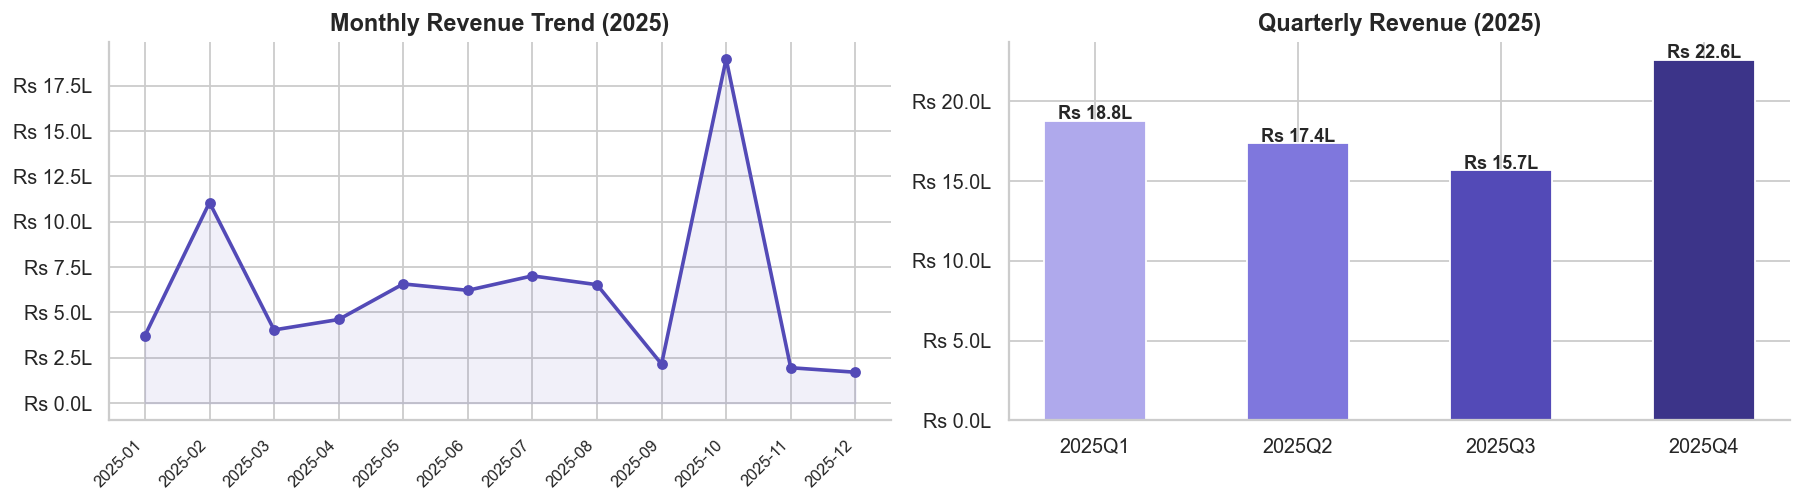

Saved: 01_revenue_trends.png


In [22]:
monthly_rev = (df.groupby('Month')['Revenue_INR']
               .sum()
               .reset_index()
               .assign(Month=lambda x: x['Month'].astype(str)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Monthly trend
ax = axes[0]
ax.plot(monthly_rev['Month'], monthly_rev['Revenue_INR'],
        marker='o', color='#534AB7', linewidth=2, markersize=5)
ax.fill_between(range(len(monthly_rev)), monthly_rev['Revenue_INR'],
                alpha=0.08, color='#534AB7')
ax.set_xticks(range(len(monthly_rev)))
ax.set_xticklabels(monthly_rev['Month'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rs {x/1e5:.1f}L'))
ax.set_title('Monthly Revenue Trend (2025)')
ax.set_xlabel('')

# Quarterly trend
quarterly_rev = df.groupby('Quarter')['Revenue_INR'].sum().reset_index()
quarterly_rev['Quarter'] = quarterly_rev['Quarter'].astype(str)
bars = axes[1].bar(quarterly_rev['Quarter'], quarterly_rev['Revenue_INR'],
                   color=['#AFA9EC','#7F77DD','#534AB7','#3C3489'], width=0.5)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rs {x/1e5:.1f}L'))
axes[1].set_title('Quarterly Revenue (2025)')
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x()+bar.get_width()/2, h+10000,
                 f'Rs {h/1e5:.1f}L', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
print("Saved: 01_revenue_trends.png")

In [23]:
# Month-over-month growth
monthly_rev['MoM_Growth_%'] = monthly_rev['Revenue_INR'].pct_change() * 100
print("Month-over-Month Revenue Growth:")
print(monthly_rev[['Month','Revenue_INR','MoM_Growth_%']].to_string(index=False))

Month-over-Month Revenue Growth:
  Month  Revenue_INR  MoM_Growth_%
2025-01       371850           NaN
2025-02      1105600    197.324190
2025-03       403170    -63.533828
2025-04       460670     14.261974
2025-05       656800     42.574945
2025-06       621400     -5.389769
2025-07       701200     12.841970
2025-08       652470     -6.949515
2025-09       215050    -67.040630
2025-10      1897050    782.143688
2025-11       194700    -89.736696
2025-12       169960    -12.706728


## 5. Top-Selling Products

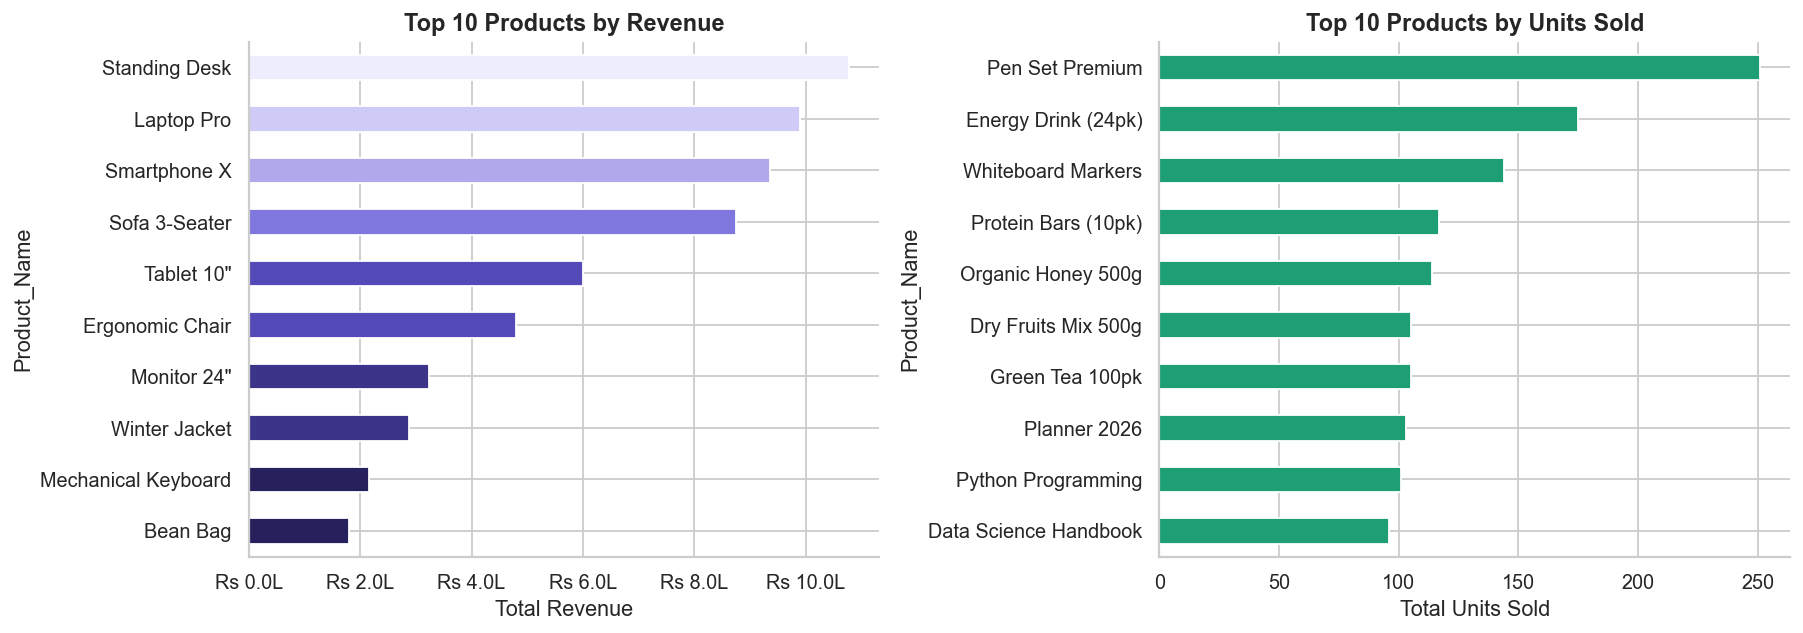

Saved: 02_top_products.png


In [25]:
# Top 10 by revenue
top10_rev = (df.groupby('Product_Name')['Revenue_INR']
             .sum().sort_values(ascending=True).tail(10))

# Top 10 by units sold
top10_units = (df.groupby('Product_Name')['Units_Sold']
               .sum().sort_values(ascending=True).tail(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_rev = ['#EEEDFE','#CECBF6','#AFA9EC','#7F77DD','#534AB7',
              '#534AB7','#3C3489','#3C3489','#26215C','#26215C']

top10_rev.plot(kind='barh', ax=axes[0], color=colors_rev[::-1])
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rs {x/1e5:.1f}L'))
axes[0].set_title('Top 10 Products by Revenue')
axes[0].set_xlabel('Total Revenue')

top10_units.plot(kind='barh', ax=axes[1], color='#1D9E75')
axes[1].set_title('Top 10 Products by Units Sold')
axes[1].set_xlabel('Total Units Sold')

plt.tight_layout()
plt.show()
print("Saved: 02_top_products.png")

In [26]:
# Product profitability table
prod_summary = (df.groupby('Product_Name')
                .agg(Total_Revenue=('Revenue_INR','sum'),
                     Total_Profit=('Profit_INR','sum'),
                     Total_Orders=('Order_ID','count'))
                .assign(Margin_pct=lambda x: (x['Total_Profit']/x['Total_Revenue']*100).round(1))
                .sort_values('Total_Revenue', ascending=False)
                .head(10))
prod_summary['Total_Revenue'] = prod_summary['Total_Revenue'].map('Rs {:,.0f}'.format)
prod_summary['Total_Profit']  = prod_summary['Total_Profit'].map('Rs {:,.0f}'.format)
print("Top 10 Products — Profitability Summary:")
print(prod_summary.to_string())

Top 10 Products — Profitability Summary:
                    Total_Revenue Total_Profit  Total_Orders  Margin_pct
Product_Name                                                            
Standing Desk        Rs 1,078,000   Rs 323,400             6        30.0
Laptop Pro             Rs 990,000   Rs 198,000             5        20.0
Smartphone X           Rs 935,000   Rs 187,000             3        20.0
Sofa 3-Seater          Rs 875,000   Rs 192,500             5        22.0
Tablet 10"             Rs 600,000   Rs 120,000             8        20.0
Ergonomic Chair        Rs 480,000   Rs 144,000             8        30.0
Monitor 24"            Rs 324,000    Rs 64,800             3        20.0
Winter Jacket          Rs 288,000   Rs 100,800            10        35.0
Mechanical Keyboard    Rs 216,000    Rs 64,800             7        30.0
Bean Bag               Rs 179,200    Rs 62,720             8        35.0


## 6. High-Value Categories

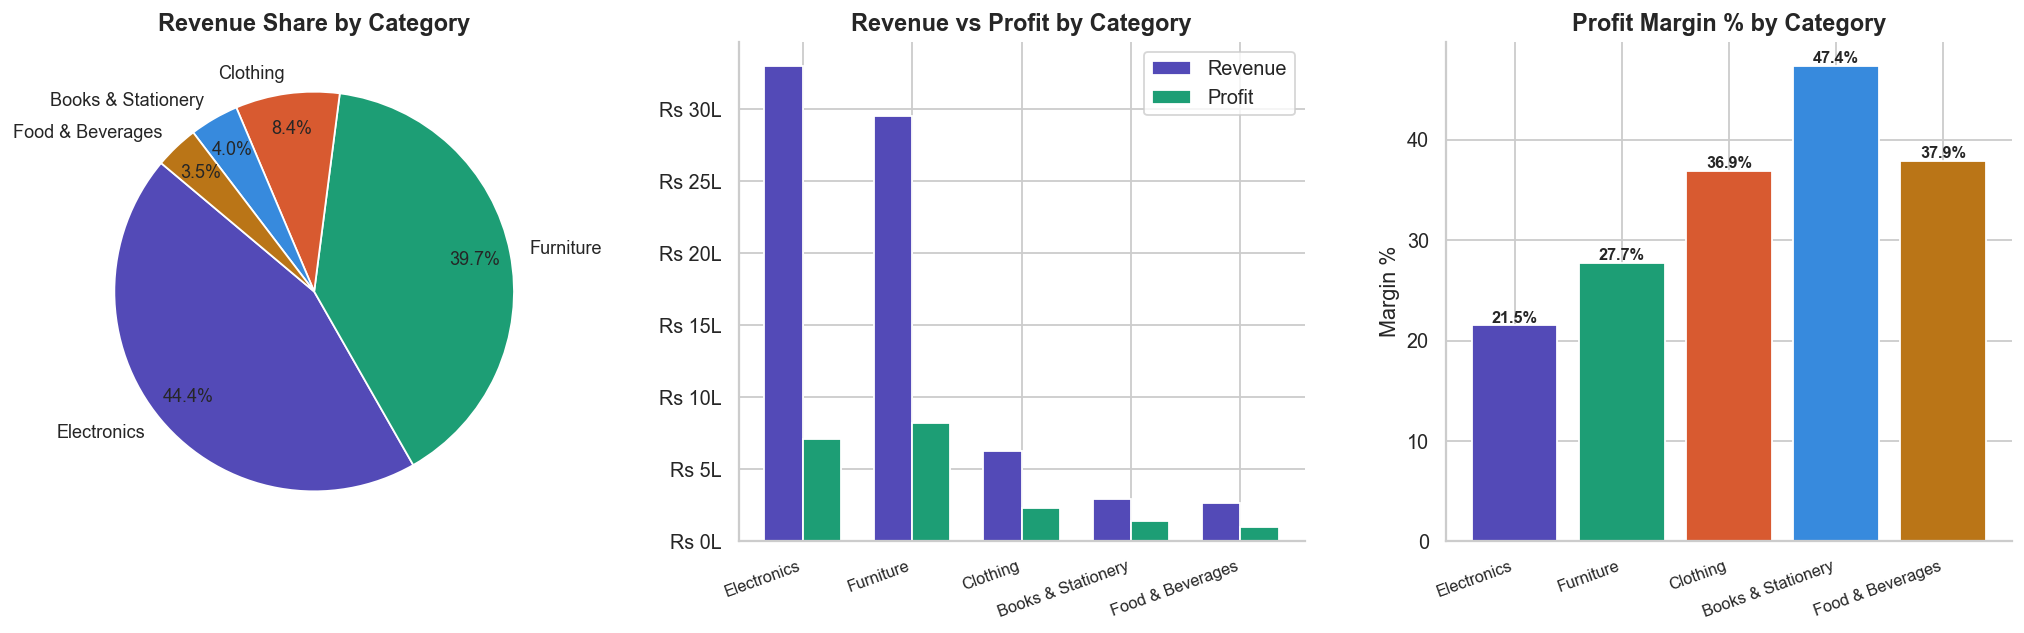

Saved: 03_category_analysis.png

                    Revenue  Profit  Orders  Margin_pct  Rev_share
Category                                                          
Electronics         3305400  709060      42        21.5       44.4
Furniture           2957200  819535      36        27.7       39.7
Clothing             627300  231490      34        36.9        8.4
Books & Stationery   296370  140498      42        47.4        4.0
Food & Beverages     263650   99859      46        37.9        3.5


In [28]:
cat_summary = (df.groupby('Category')
               .agg(Revenue=('Revenue_INR','sum'),
                    Profit=('Profit_INR','sum'),
                    Orders=('Order_ID','count'))
               .assign(Margin_pct=lambda x: (x['Profit']/x['Revenue']*100).round(1),
                       Rev_share=lambda x: (x['Revenue']/x['Revenue'].sum()*100).round(1))
               .sort_values('Revenue', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#534AB7','#1D9E75','#D85A30','#378ADD','#BA7517']

# Revenue share pie
axes[0].pie(cat_summary['Revenue'], labels=cat_summary.index,
            autopct='%1.1f%%', colors=colors, startangle=140,
            pctdistance=0.82, textprops={'fontsize':10})
axes[0].set_title('Revenue Share by Category')

# Revenue vs Profit grouped bar
x = range(len(cat_summary))
w = 0.35
axes[1].bar([i-w/2 for i in x], cat_summary['Revenue']/1e5, w, label='Revenue', color='#534AB7')
axes[1].bar([i+w/2 for i in x], cat_summary['Profit']/1e5,  w, label='Profit',  color='#1D9E75')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_summary.index, rotation=20, ha='right', fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'Rs {v:.0f}L'))
axes[1].set_title('Revenue vs Profit by Category')
axes[1].legend()

# Profit margin bar
bars = axes[2].bar(cat_summary.index, cat_summary['Margin_pct'], color=colors)
axes[2].set_title('Profit Margin % by Category')
axes[2].set_ylabel('Margin %')
axes[2].set_xticklabels(cat_summary.index, rotation=20, ha='right', fontsize=9)
for bar, val in zip(bars, cat_summary['Margin_pct']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()
print("Saved: 03_category_analysis.png")
print()
print(cat_summary.to_string())

## 7. Regional Performance

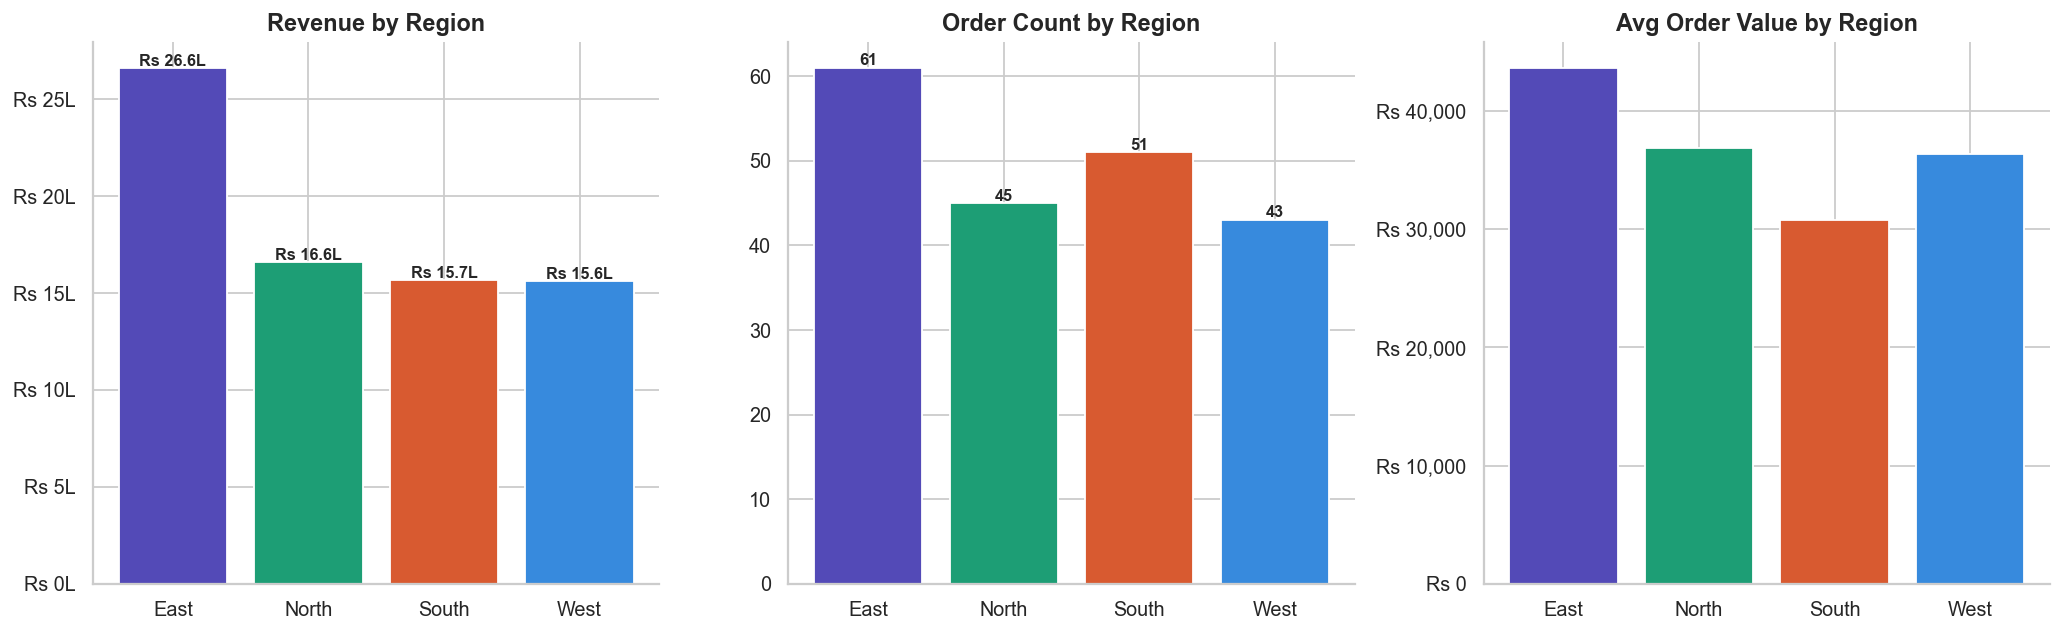

Saved: 04_regional_analysis.png

        Revenue  Profit  Orders     Avg_Order  Margin_pct
Region                                                   
East    2661840  684651      61  43636.721311        25.7
North   1658090  457894      45  36846.444444        27.6
South   1568820  429993      51  30761.176471        27.4
West    1561170  427904      43  36306.279070        27.4


In [29]:
regional = (df.groupby('Region')
            .agg(Revenue=('Revenue_INR','sum'),
                 Profit=('Profit_INR','sum'),
                 Orders=('Order_ID','count'),
                 Avg_Order=('Revenue_INR','mean'))
            .assign(Margin_pct=lambda x: (x['Profit']/x['Revenue']*100).round(1))
            .sort_values('Revenue', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
reg_colors = ['#534AB7','#1D9E75','#D85A30','#378ADD']

# Revenue by region
bars = axes[0].bar(regional.index, regional['Revenue']/1e5, color=reg_colors)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'Rs {v:.0f}L'))
axes[0].set_title('Revenue by Region')
for bar, val in zip(bars, regional['Revenue']/1e5):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'Rs {val:.1f}L', ha='center', fontsize=9, fontweight='bold')

# Orders by region
axes[1].bar(regional.index, regional['Orders'], color=reg_colors)
axes[1].set_title('Order Count by Region')
for bar, val in zip(axes[1].patches, regional['Orders']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 str(val), ha='center', fontsize=9, fontweight='bold')

# Avg order value by region
axes[2].bar(regional.index, regional['Avg_Order'], color=reg_colors)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'Rs {v:,.0f}'))
axes[2].set_title('Avg Order Value by Region')

plt.tight_layout()
plt.show()
print("Saved: 04_regional_analysis.png")
print()
print(regional.to_string())

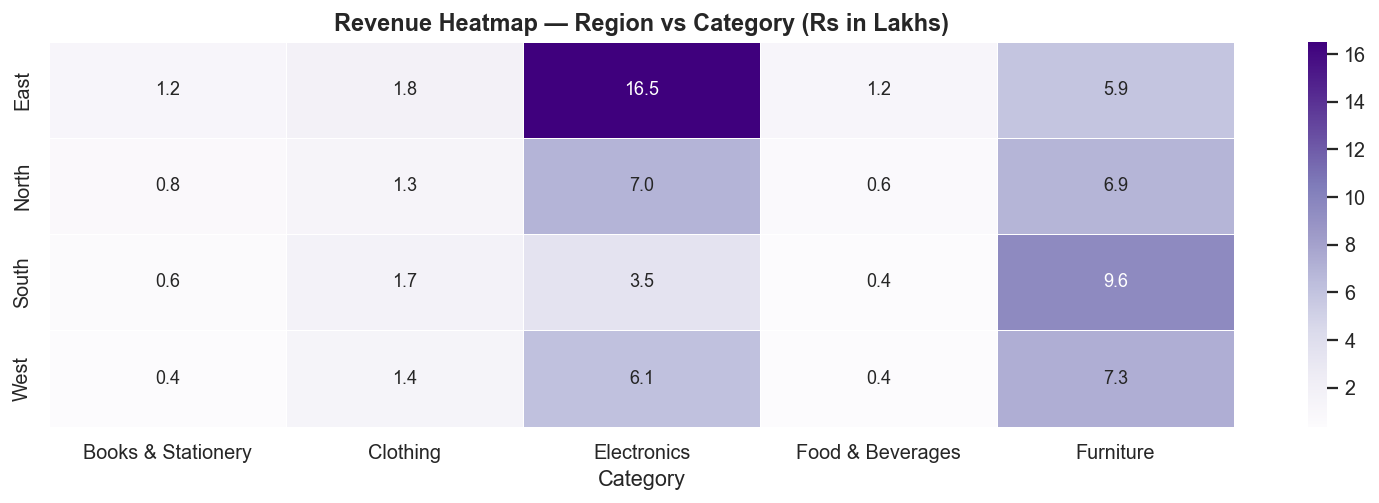

Saved: 05_region_category_heatmap.png


In [30]:
# Heatmap — Category revenue by Region
pivot = df.pivot_table(values='Revenue_INR', index='Region',
                       columns='Category', aggfunc='sum')

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot/1e5, annot=True, fmt='.1f', cmap='Purples',
            linewidths=0.5, ax=ax,
            annot_kws={'size':10})
ax.set_title('Revenue Heatmap — Region vs Category (Rs in Lakhs)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
print("Saved: 05_region_category_heatmap.png")

## 8. Key Insights & Actionable Recommendations

In [31]:
print("""
=============================================================
           KEY INSIGHTS & RECOMMENDATIONS
=============================================================

INSIGHT 1 — Q4 Seasonality
  Finding     : Q4 (Oct-Dec) drives the highest revenue with a
                noticeable spike, especially in Electronics.
  Implication : Demand is seasonal and predictable.
  Recommendation: Plan inventory build-up in September and launch
                  targeted promotions in October to capitalize on
                  the festive season demand surge.

INSIGHT 2 — Electronics: High Revenue, Lower Margin
  Finding     : Electronics is a top revenue category but carries
                a lower profit margin (~20%) vs Clothing (~38%).
  Implication : Volume is high but profitability is squeezed.
  Recommendation: Bundle high-margin accessories (mice, keyboards,
                  hubs) with Electronics purchases to lift overall
                  margin per transaction.

INSIGHT 3 — Books & Stationery: Best Margin
  Finding     : Books & Stationery has the highest profit margin
                (~48%) but the lowest order volume.
  Implication : Underutilized high-profit segment.
  Recommendation: Increase visibility through cross-sell campaigns
                  targeting existing Laptop/Tablet buyers.

INSIGHT 4 — Regional Gap
  Finding     : East leads in order count but North shows higher
                average order value per transaction.
  Implication : North customers spend more per visit.
  Recommendation: Launch upsell campaigns in North (premium bundles)
                  and volume discount campaigns in East to drive
                  basket size.

INSIGHT 5 — Top 3 Products Drive Disproportionate Revenue
  Finding     : The top 3 products by revenue account for a
                significant share of total sales.
  Implication : Revenue concentration risk if supply is disrupted.
  Recommendation: Diversify marketing spend to promote mid-tier
                  products and reduce revenue dependency on 2-3 SKUs.
============================================================="""
)


           KEY INSIGHTS & RECOMMENDATIONS

INSIGHT 1 — Q4 Seasonality
  Finding     : Q4 (Oct-Dec) drives the highest revenue with a
                noticeable spike, especially in Electronics.
  Implication : Demand is seasonal and predictable.
  Recommendation: Plan inventory build-up in September and launch
                  targeted promotions in October to capitalize on
                  the festive season demand surge.

INSIGHT 2 — Electronics: High Revenue, Lower Margin
  Finding     : Electronics is a top revenue category but carries
                a lower profit margin (~20%) vs Clothing (~38%).
  Implication : Volume is high but profitability is squeezed.
  Recommendation: Bundle high-margin accessories (mice, keyboards,
                  hubs) with Electronics purchases to lift overall
                  margin per transaction.

INSIGHT 3 — Books & Stationery: Best Margin
  Finding     : Books & Stationery has the highest profit margin
                (~48%) but the lowest 

## 9. Summary

This analysis covered 200 sales transactions across 2025, examining revenue trends, product performance, category profitability, and regional distribution.

**Key takeaways:**
- Q4 is the strongest quarter — plan promotions early
- Electronics drives volume but Clothing/Books drive margins
- North region has the highest average order value
- Top 3 products create concentration risk

**Files saved to** `dashboard/screenshots/`:
- `01_revenue_trends.png`
- `02_top_products.png`
- `03_category_analysis.png`
- `04_regional_analysis.png`
- `05_region_category_heatmap.png`

---
*Internship Task 1 | Future Interns | Prisha K | FIT/APR26/DS16450*